# 核心版：階層模型——捕手、主審、投手效應同時估計

兩階段交叉隨機截距模型（見 `models/hierarchical.py`）：

$$\text{logit}\,P(\text{strike}) = \beta_0 + \beta_1\,\text{logit\_base} + \theta_{catcher} + \varphi_{umpire} + \psi_{pitcher}$$

$$\theta_{catcher}\sim N(0,\tau_c^2),\quad \varphi_{umpire}\sim N(0,\tau_u^2),\quad \psi_{pitcher}\sim N(0,\tau_p^2)$$

- 第一層 GAM 的 logit 當 covariate（凍結），第二層只估三組隨機效應。
- 捕手/主審/投手同時進模型互相競爭。好捕手常配到好投手或好主審，不放進來的話這些殘差會一併記到捕手頭上。
- θ 的後驗均值即**收縮後**的捕手效應（樣本少者被拉向 0）。

θ 應讀作「在這個模型設定下與捕手相關的變異」，不是識別出來的因果效應——
球種、球速、位移、打者身分、球場都還沒進模型，捕手與投手也不是隨機配對。

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from models.hierarchical import load_cached
from models.framing_runs import load_baseline, framing_leaderboard, add_names, merge_official
from data.official import fetch_official_framing

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Arial Unicode MS', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

effects, hier, meta = load_cached(2023)   # 載入快取（不存在才 fit，約 5-8 分）
print('固定效應  β0 =', round(meta['intercept'],3), ', β1(logit_base) =', round(meta['slope'],3))
print('變異成分 τ :', {k: round(v,3) for k,v in meta['tau'].items()})

固定效應  β0 = -0.016 , β1(logit_base) = 1.031
變異成分 τ : {'catcher': 0.192, 'umpire': 0.233, 'pitcher': 0.199}


## 變異成分與信度

τ 是各組效應的標準差（logit 尺度）。捕手 τ_c 明顯 > 0 代表 framing 是真實、可辨識的技術；
同時主審 τ_u、投手 τ_p 也 > 0，證明這些混淆因子確實存在、必須控制。

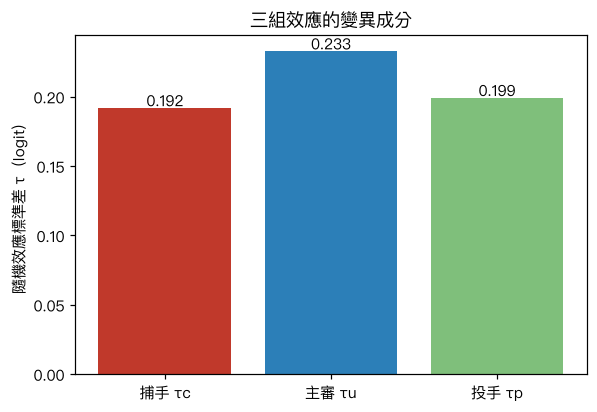

主審效應散布通常最大——主審個人好球帶差異其實比捕手 framing 更大。


In [2]:
tau = meta['tau']
fig, ax = plt.subplots(figsize=(6,4))
groups = ['catcher','umpire','pitcher']; labels=['捕手 τc','主審 τu','投手 τp']
ax.bar(labels, [tau[g] for g in groups], color=['#c0392b','#2c7fb8','#7fbf7b'])
for i,g in enumerate(groups): ax.text(i, tau[g], f'{tau[g]:.3f}', ha='center', va='bottom')
ax.set_ylabel('隨機效應標準差 τ（logit）'); ax.set_title('三組效應的變異成分')
fig.savefig('../figures/hier_variance_components_2023.png', bbox_inches='tight'); plt.show()
print('主審效應散布通常最大——主審個人好球帶差異其實比捕手 framing 更大。')

## Shrinkage：簡單版 vs 階層版

把週 5 簡單版 framing runs（未控制、未收縮）與階層版（控制混淆 + 收縮）並排。
樣本少的替補捕手在階層版被拉向 0——這就是 shrinkage 在防止過度解讀小樣本。

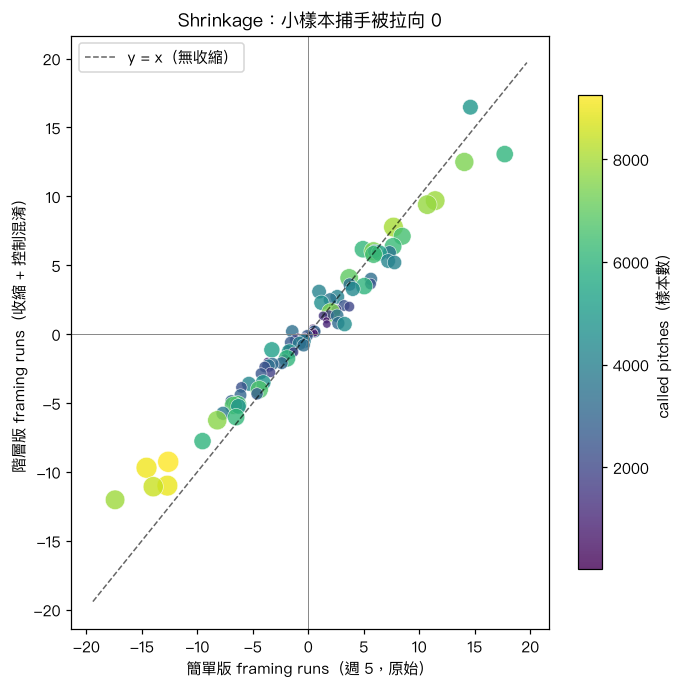

In [3]:
simple = add_names(framing_leaderboard(load_baseline(2023)))
hier_named = add_names(hier.rename({'framing_runs_model':'framing_runs'})).rename({'framing_runs':'framing_runs_model'})
cmp = simple.select(['mlbam_id','name','called_pitches','framing_runs']).join(
    hier.select(['mlbam_id','framing_runs_model','catcher_effect']), on='mlbam_id', how='inner')

x = cmp['framing_runs'].to_numpy(); y = cmp['framing_runs_model'].to_numpy()
n = cmp['called_pitches'].to_numpy()
fig, ax = plt.subplots(figsize=(7,7))
lim=[min(x.min(),y.min())-2, max(x.max(),y.max())+2]
ax.plot(lim,lim,'k--',lw=1,alpha=0.6,label='y = x（無收縮）')
sizes = 10 + (n/ n.max())*180
sc = ax.scatter(x, y, s=sizes, c=n, cmap='viridis', alpha=0.8, edgecolor='white', linewidth=0.4)
fig.colorbar(sc, ax=ax, label='called pitches（樣本數）', shrink=0.8)
ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
ax.set_xlabel('簡單版 framing runs（週 5，原始）')
ax.set_ylabel('階層版 framing runs（收縮 + 控制混淆）')
ax.set_title('Shrinkage：小樣本捕手被拉向 0'); ax.legend(loc='upper left')
fig.savefig('../figures/hier_shrinkage_2023.png', bbox_inches='tight'); plt.show()

## 階層版排行榜與官方對照

控制主審/投手後，與官方榜單的相關性是否維持？

In [4]:
official = fetch_official_framing(2023)
m = hier.join(official.select(pl.col('id').alias('mlbam_id'), pl.col('rv_tot').alias('official_runs')),
              on='mlbam_id', how='inner')
x = m['official_runs'].to_numpy(); y = m['framing_runs_model'].to_numpy()
pr,_ = pearsonr(x,y); sr,_ = spearmanr(x,y)
print(f'合格捕手 n={len(m)}  Pearson r={pr:.3f}  Spearman r={sr:.3f}')

top = add_names(hier).filter(pl.col('called_pitches')>=2000)
print('\n=== 階層版前 10 ===')
print(top.head(10).select(['name','called_pitches','catcher_effect','framing_runs_model']))
print('\n=== 階層版後 5 ===')
print(top.sort('framing_runs_model').head(5).select(['name','called_pitches','catcher_effect','framing_runs_model']))

合格捕手 n=63  Pearson r=0.980  Spearman r=0.979

=== 階層版前 10 ===
shape: (10, 4)
┌────────────────────┬────────────────┬────────────────┬────────────────────┐
│ name               ┆ called_pitches ┆ catcher_effect ┆ framing_runs_model │
│ ---                ┆ ---            ┆ ---            ┆ ---                │
│ str                ┆ u32            ┆ f64            ┆ f64                │
╞════════════════════╪════════════════╪════════════════╪════════════════════╡
│ Hedges, Austin     ┆ 4865           ┆ 0.515851       ┆ 16.473416          │
│ Bailey, Patrick    ┆ 6038           ┆ 0.333394       ┆ 13.067044          │
│ Álvarez, Francisco ┆ 7430           ┆ 0.277786       ┆ 12.497172          │
│ Heim, Jonah        ┆ 7870           ┆ 0.196747       ┆ 9.691811           │
│ Contreras, William ┆ 7802           ┆ 0.191607       ┆ 9.401879           │
│ Raleigh, Cal       ┆ 7992           ┆ 0.157308       ┆ 7.769239           │
│ Rogers, Jake       ┆ 6487           ┆ 0.169824       ┆ 7.107668

## 混淆修正：簡單版與階層版差最多的捕手

差距大者，就是簡單版把「常配好投手/好主審」的紅利錯算到捕手頭上、被階層模型修正掉的。

In [5]:
movers = cmp.with_columns(shift=(pl.col('framing_runs_model')-pl.col('framing_runs'))).sort(
    pl.col('shift').abs(), descending=True)
print(movers.select(['name','called_pitches','framing_runs','framing_runs_model','shift']).head(8))

shape: (8, 5)
┌───────────────────┬────────────────┬──────────────┬────────────────────┬───────────┐
│ name              ┆ called_pitches ┆ framing_runs ┆ framing_runs_model ┆ shift     │
│ ---               ┆ ---            ┆ ---          ┆ ---                ┆ ---       │
│ str               ┆ u32            ┆ f64          ┆ f64                ┆ f64       │
╞═══════════════════╪════════════════╪══════════════╪════════════════════╪═══════════╡
│ Maldonado, Martín ┆ 7891           ┆ -17.411188   ┆ -12.022511         ┆ 5.388677  │
│ Langeliers, Shea  ┆ 9062           ┆ -14.577821   ┆ -9.69814           ┆ 4.879682  │
│ Bailey, Patrick   ┆ 6038           ┆ 17.710685    ┆ 13.067044          ┆ -4.643641 │
│ Realmuto, J. T.   ┆ 9250           ┆ -12.620113   ┆ -9.265702          ┆ 3.354411  │
│ Díaz, Elías       ┆ 8462           ┆ -13.969135   ┆ -11.073748         ┆ 2.895387  │
│ Caratini, Víctor  ┆ 4072           ┆ 7.776054     ┆ 5.203498           ┆ -2.572557 │
│ Sánchez, Gary     ┆ 4522   

## 主審好球帶：附帶產出

同一個模型也估出主審效應 φ_umpire——好球帶最鬆/最緊的主審。

In [6]:
ump = effects.filter(pl.col('group')=='umpire').sort('effect_mean', descending=True)
from pybaseball import playerid_reverse_lookup
ids = ump['mlbam_id'].to_list()
look = playerid_reverse_lookup(ids, key_type='mlbam')
names = pl.from_pandas(look[['key_mlbam','name_first','name_last']]).with_columns(
    name=(pl.col('name_first').str.to_titlecase()+' '+pl.col('name_last').str.to_titlecase())
).select(pl.col('key_mlbam').alias('mlbam_id'),'name')
ump = ump.join(names, on='mlbam_id', how='left')
print('好球帶最鬆（θ>0，愛給好球）前 5:'); print(ump.head(5).select(['name','effect_mean']))
print('\n好球帶最緊（θ<0）前 5:'); print(ump.sort('effect_mean').head(5).select(['name','effect_mean']))

好球帶最鬆（θ>0，愛給好球）前 5:
shape: (5, 2)
┌───────────────┬─────────────┐
│ name          ┆ effect_mean │
│ ---           ┆ ---         │
│ str           ┆ f64         │
╞═══════════════╪═════════════╡
│ Doug Eddings  ┆ 0.808572    │
│ Bill Miller   ┆ 0.545712    │
│ Lance Barrett ┆ 0.44144     │
│ Gabe Morales  ┆ 0.319121    │
│ Jeff Nelson   ┆ 0.272148    │
└───────────────┴─────────────┘

好球帶最緊（θ<0）前 5:
shape: (5, 2)
┌────────────────┬─────────────┐
│ name           ┆ effect_mean │
│ ---            ┆ ---         │
│ str            ┆ f64         │
╞════════════════╪═════════════╡
│ Adrian Johnson ┆ -0.61405    │
│ Mark Wegner    ┆ -0.466197   │
│ Pat Hoberg     ┆ -0.410397   │
│ John Bacon     ┆ -0.394393   │
│ David Arrieta  ┆ -0.32288    │
└────────────────┴─────────────┘


## 觀察

- 捕手 τ_c 明顯 > 0：捕手之間確實存在可辨識、非零的差異。
- 主審、投手 τ 也 > 0，而且主審最大——這些混淆因子確實存在，未調整版會把它們算進捕手頭上。
- Shrinkage 把小樣本替補捕手拉向 0，避免過度解讀。
- 「修正幅度最大」的捕手，正是未調整版把主審/投手殘差算進去最多的那幾位。
- 下一步：split-half 信度、年度間相關，量化這個測量的穩定度。

**限制**：VB 在預設迭代上限內未完全收斂（level 多時常見），但固定效應（β1≈1.03）與
τ 估計穩定合理、與子樣本結果一致，合成資料也能正確還原（見 tests/test_random_effects.py）；
更嚴謹可增加迭代、或改用 glmmTMB(R) 的 MLE。投手 <100 顆併為一組是計算取捨。
另外，本模型未控制球種、球速、球場與打者身分，估計值屬關聯而非因果。